# Analyse de la rentabilité des remises — Superstore

**Objectif :** Construire un modèle Random Forest pour prédire si une remise est **rentable** ou non, et identifier les profils (client, produit, région) où les remises ont le plus d'impact positif.

**Logique métier :** Une remise est considérée rentable si le revenu généré avec remise est **supérieur au revenu moyen sans remise** pour la même sous-catégorie.


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Style global des graphiques
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print('✅ Imports OK')

✅ Imports OK


## 2. Chargement et Nettoyage des données

Le CSV a plusieurs particularités à gérer :
- Séparateur `;`
- Montants avec `$`, espaces, et virgules décimales (format européen)
- Remises en `%`
- Dates en `DD/MM/YYYY`

In [2]:
# --- Chargement ---
df = pd.read_csv('excel_project_s2.csv', sep=';', encoding='utf-8-sig')

# Nettoyage des noms de colonnes (espaces parasites)
df.columns = df.columns.str.strip()

# --- Nettoyage des colonnes monétaires ---
def clean_money(col):
    """Supprime $, espaces insécables, espaces normaux, remplace , par . et convertit en float."""
    return (
        col.astype(str)
           .str.replace('$', '', regex=False)
           .str.replace('\xa0', '', regex=False)  # espace insécable
           .str.replace(' ', '', regex=False)
           .str.replace(',', '.', regex=False)
           .astype(float)
    )

df['Total Amount'] = clean_money(df['Total Amount'])
df['Total Amount After the Discount'] = clean_money(df['Total Amount After the Discount'])

# --- Nettoyage de la remise ---
df['Discount'] = (
    df['Discount'].astype(str)
                  .str.replace('%', '', regex=False)
                  .str.replace(',', '.', regex=False)
                  .astype(float) / 100
)

# --- Parsing des dates ---
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y')

# --- Nettoyage des strings (espaces dans City) ---
df['City']  = df['City'].str.strip()
df['State'] = df['State'].str.strip()

print(f'✅ Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes')
df.head(3)

✅ Dataset chargé : 150 lignes, 21 colonnes


,Order ID,Customer ID,Customer Name,Product ID,Product Name,Postal Code,City,State,Order Date,Total Amount,...,Discount,Ship Date,Category,Sub-Category,Ship Mode,Segment,Region,Regional Manager,Regional Manager Email,Total Amount After the Discount
0,CA-2016-152156,CG-12520,Claire Gute,FUR-BO-10001798,Bush Somerset Collection Bookcase,42420,Henderson,Kentucky,2016-11-08,261.96,...,0.00,2016-11-11,Furniture,Bookcases,Second Class,CONSUMER,South,Charlie Brown,cbrown@superstore.com,261.96
1,CA-2016-152156,CG-12520,Claire Gute,FUR-CH-10000454,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",42420,Henderson,Kentucky,2016-11-08,731.94,...,0.00,2016-11-11,Furniture,Chairs,Second Class,CONSUMER,South,Charlie Brown,cbrown@superstore.com,731.94
2,US-2015-108966,SO-20335,Sean O'Donnell,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,33311,Fort Lauderdale,Florida,2015-10-11,957.58,...,0.45,2015-10-18,Furniture,Tables,Standard Class,CONSUMER,South,Charlie Brown,cbrown@superstore.com,526.67


In [3]:
# Vérification des valeurs manquantes
missing = df.isnull().sum()
print('Valeurs manquantes par colonne :')
print(missing[missing > 0] if missing.any() else '  Aucune ✅')

print('\nTypes des colonnes numériques :')
print(df[['Total Amount', 'Total Amount After the Discount', 'Discount', 'Quantity']].dtypes)

Valeurs manquantes par colonne :
  Aucune ✅

Types des colonnes numériques :
Total Amount                       float64
Total Amount After the Discount    float64
Discount                           float64
Quantity                             int64
dtype: object


## 3. Feature Engineering

### 3.1 Variable cible : `remise_rentable`

On calcule le **revenu moyen par unité sans remise** pour chaque sous-catégorie, puis on vérifie si le revenu réel de la commande dépasse ce benchmark.

In [4]:
# Prix unitaire réel payé
df['prix_unitaire_paye'] = df['Total Amount After the Discount'] / df['Quantity']

# Prix moyen sans remise par sous-catégorie (commandes sans remise uniquement)
prix_ref = (
    df[df['Discount'] == 0]
    .groupby('Sub-Category')['prix_unitaire_paye']
    .mean()
    .rename('prix_ref_unitaire')
)

df = df.merge(prix_ref, on='Sub-Category', how='left')

# Pour les sous-catégories sans données sans remise → on prend la médiane globale
fallback = df[df['Discount'] == 0]['prix_unitaire_paye'].median()
df['prix_ref_unitaire'] = df['prix_ref_unitaire'].fillna(fallback)

# Revenu de référence (ce qu'on aurait gagné sans remise pour la même quantité)
df['revenu_reference'] = df['prix_ref_unitaire'] * df['Quantity']

# La remise est rentable si le revenu réel >= revenu de référence
df['remise_rentable'] = (df['Total Amount After the Discount'] >= df['revenu_reference']).astype(int)

# On ne s'intéresse qu'aux commandes avec remise
df_remise = df[df['Discount'] > 0].copy()

print(f'Commandes avec remise : {len(df_remise)}')
print(f"\nDistribution de la variable cible :")
print(df_remise['remise_rentable'].value_counts().rename({0: 'Non rentable', 1: 'Rentable'}))

Commandes avec remise : 73

Distribution de la variable cible :
remise_rentable
Non rentable    52
Rentable        21
Name: count, dtype: int64


### 3.2 Nouvelles features

In [5]:
# Délai de livraison (jours)
df_remise['delai_livraison'] = (df_remise['Ship Date'] - df_remise['Order Date']).dt.days

# Mois et année de la commande
df_remise['mois_commande'] = df_remise['Order Date'].dt.month
df_remise['annee_commande'] = df_remise['Order Date'].dt.year

# Perte brute due à la remise
df_remise['perte_remise'] = df_remise['Total Amount'] - df_remise['Total Amount After the Discount']

print('✅ Features créées')
df_remise[['Discount', 'Quantity', 'delai_livraison', 'perte_remise', 'remise_rentable']].describe()

✅ Features créées


,Discount,Quantity,delai_livraison,perte_remise,remise_rentable
count,73.000000,73.000000,73.000000,73.000000,73.000000
mean,0.310548,4.178082,4.164384,72.905068,0.287671
std,0.199819,2.468369,1.462624,193.934304,0.455810
min,0.100000,1.000000,1.000000,0.650000,0.000000
25%,0.200000,2.000000,3.000000,5.450000,0.000000
50%,0.200000,3.000000,4.000000,18.780000,0.000000
75%,0.300000,6.000000,5.000000,48.800000,1.000000
max,0.800000,14.000000,7.000000,1541.710000,1.000000


## 4. Analyse Exploratoire (EDA)

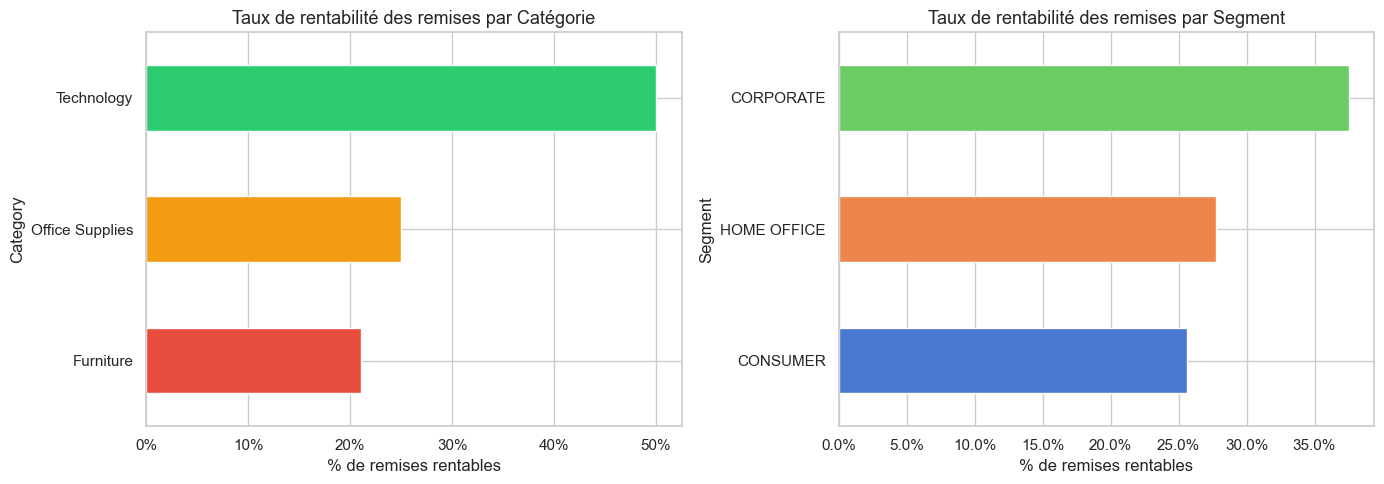

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de rentabilité par catégorie
cat_rentab = df_remise.groupby('Category')['remise_rentable'].mean().sort_values()
cat_rentab.plot(kind='barh', ax=axes[0], color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Taux de rentabilité des remises par Catégorie')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_xlabel('% de remises rentables')

# Taux de rentabilité par Segment
seg_rentab = df_remise.groupby('Segment')['remise_rentable'].mean().sort_values()
seg_rentab.plot(kind='barh', ax=axes[1], color=sns.color_palette('muted', 3))
axes[1].set_title('Taux de rentabilité des remises par Segment')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].set_xlabel('% de remises rentables')

plt.tight_layout()
plt.savefig('plots/rentabilite_categorie_segment.png', dpi=150, bbox_inches='tight')
plt.show()

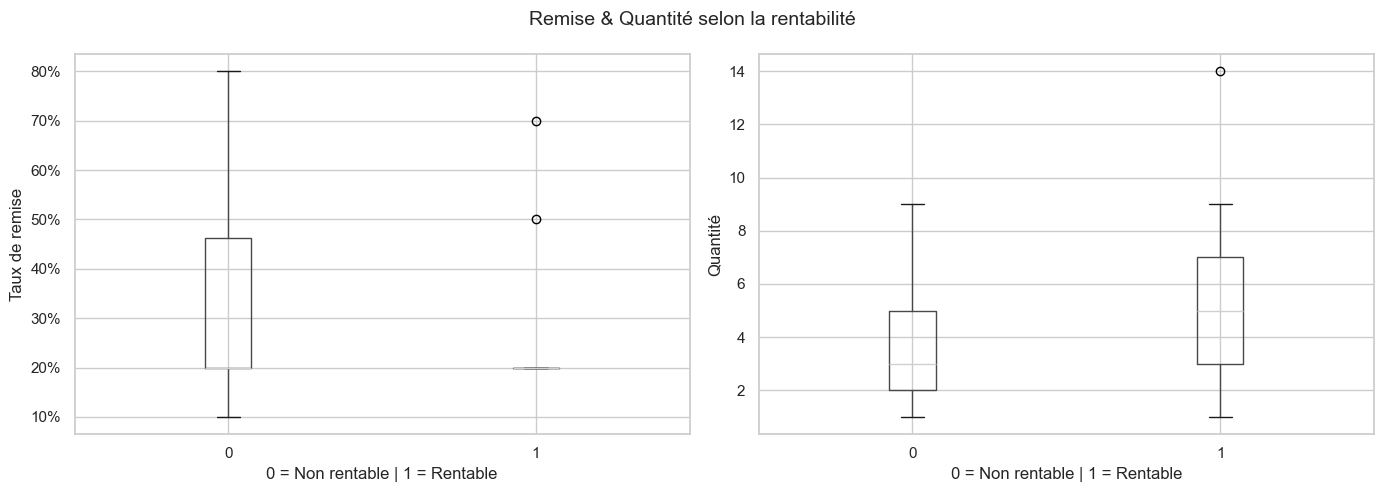

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution du taux de remise selon la rentabilité
df_remise.boxplot(column='Discount', by='remise_rentable', ax=axes[0])
axes[0].set_title('Taux de remise : Rentable vs Non rentable')
axes[0].set_xlabel('0 = Non rentable | 1 = Rentable')
axes[0].set_ylabel('Taux de remise')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.sca(axes[0])
plt.title('')

# Quantité commandée selon la rentabilité
df_remise.boxplot(column='Quantity', by='remise_rentable', ax=axes[1])
axes[1].set_title('Quantité commandée : Rentable vs Non rentable')
axes[1].set_xlabel('0 = Non rentable | 1 = Rentable')
axes[1].set_ylabel('Quantité')
plt.sca(axes[1])
plt.title('')

fig.suptitle('Remise & Quantité selon la rentabilité', fontsize=14)
plt.tight_layout()
plt.savefig('plots/distribution_remise_quantite.png', dpi=150, bbox_inches='tight')
plt.show()

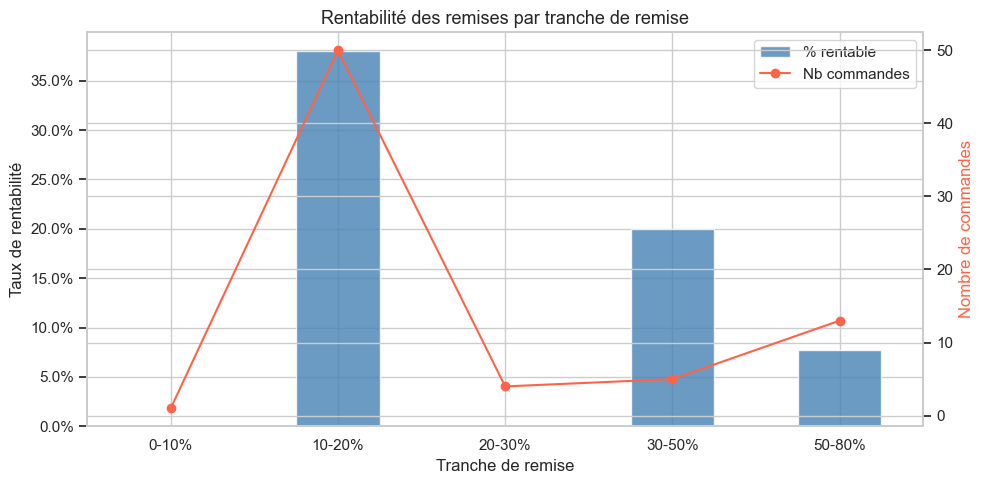

In [8]:
# Taux de rentabilité par taux de remise (discrétisé)
bins = [0, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
labels = ['0-10%', '10-20%', '20-30%', '30-50%', '50-80%', '80-100%']
df_remise['tranche_remise'] = pd.cut(df_remise['Discount'], bins=bins, labels=labels)

rentab_par_tranche = df_remise.groupby('tranche_remise', observed=True)['remise_rentable'].agg(['mean','count'])
rentab_par_tranche.columns = ['taux_rentabilite', 'nb_commandes']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

rentab_par_tranche['taux_rentabilite'].plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8, label='% rentable')
rentab_par_tranche['nb_commandes'].plot(kind='line', ax=ax2, color='tomato', marker='o', label='Nb commandes')

ax1.set_ylabel('Taux de rentabilité')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.set_ylabel('Nombre de commandes', color='tomato')
ax1.set_title('Rentabilité des remises par tranche de remise')
ax1.set_xlabel('Tranche de remise')
ax1.tick_params(axis='x', rotation=0)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('plots/rentabilite_par_tranche.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Modèle Random Forest

### 5.1 Préparation des features

In [9]:
# --- ÉTAPE 1 : Calcul des features comportementales par client ---
# On calcule sur df (tout le dataset) pour avoir l'historique complet
client_features_df = df.groupby('Customer ID').agg(
    nb_commandes        = ('Order ID',                        'nunique'),
    panier_moyen        = ('Total Amount After the Discount', 'mean'),
    remise_moy_client   = ('Discount',                        'mean'),
    quantite_moy_client = ('Quantity',                        'mean'),
    revenu_total_client = ('Total Amount After the Discount', 'sum'),
).reset_index()

# --- ÉTAPE 2 : Merge sur df_remise ---
df_remise = df_remise.merge(client_features_df, on='Customer ID', how='left')
print(f'✅ Merge OK — df_remise shape : {df_remise.shape}')

# --- ÉTAPE 3 : Définition des features ---
features_client = [
    'nb_commandes',
    'panier_moyen',
    'remise_moy_client',
    'quantite_moy_client',
    'revenu_total_client',
]

# Catégorielles (texte → LabelEncoder)
features_cat = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']

# Numériques (nombres → rien à encoder)
features_num = ['Discount', 'Quantity', 'delai_livraison', 'mois_commande'] + features_client

# --- ÉTAPE 4 : Encodage et préparation ---
df_model = df_remise[features_cat + features_num + ['remise_rentable']].copy()

encoders = {}
for col in features_cat:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

X = df_model[features_cat + features_num]
y = df_model['remise_rentable']

print(f'Features utilisées : {list(X.columns)}')
print(f'Taille dataset : {X.shape}')
print(f"Distribution cible : {y.value_counts().to_dict()}")

✅ Merge OK — df_remise shape : (73, 35)
Features utilisées : ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode', 'Discount', 'Quantity', 'delai_livraison', 'mois_commande', 'nb_commandes', 'panier_moyen', 'remise_moy_client', 'quantite_moy_client', 'revenu_total_client']
Taille dataset : (73, 14)
Distribution cible : {0: 52, 1: 21}


### 5.2 Entraînement avec Cross-Validation

In [10]:
# Split train/test (stratifié pour équilibrer les classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Modèle Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=2,
    class_weight='balanced',  # compense un éventuel déséquilibre de classes
    random_state=42
)

rf.fit(X_train, y_train)

# Cross-validation (5 folds)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f'✅ Cross-validation Accuracy : {cv_scores.mean():.2%} (+/- {cv_scores.std():.2%})')
print(f'   Scores par fold : {[f"{s:.2%}" for s in cv_scores]}')

✅ Cross-validation Accuracy : 68.57% (+/- 6.61%)
   Scores par fold : ['73.33%', '66.67%', '60.00%', '78.57%', '64.29%']


### 5.3 Évaluation sur le jeu de test

=== Rapport de classification ===
                  precision    recall  f1-score   support

Non rentable (0)       0.72      0.93      0.81        14
    Rentable (1)       0.00      0.00      0.00         5

        accuracy                           0.68        19
       macro avg       0.36      0.46      0.41        19
    weighted avg       0.53      0.68      0.60        19



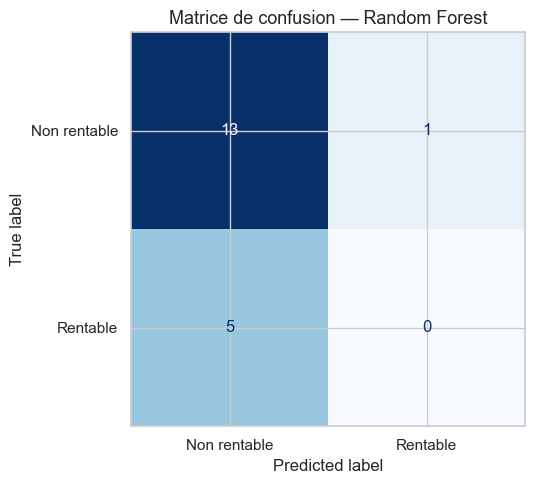

In [11]:
y_pred = rf.predict(X_test)

print('=== Rapport de classification ===')
print(classification_report(
    y_test, y_pred,
    target_names=['Non rentable (0)', 'Rentable (1)']
))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non rentable', 'Rentable'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion — Random Forest')
plt.tight_layout()
plt.savefig('plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Interprétation — Importance des features

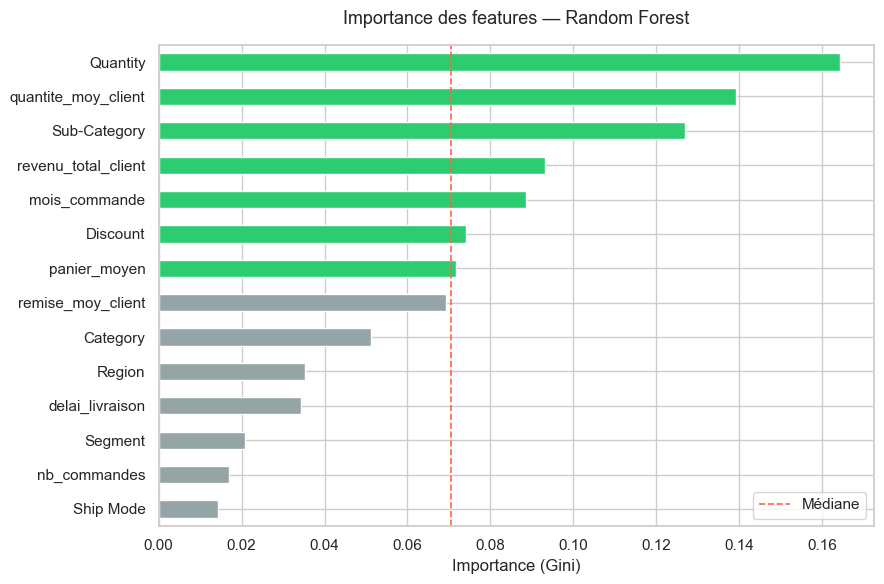


Top 3 features les plus importantes :
  → Quantity : 0.164
  → quantite_moy_client : 0.139
  → Sub-Category : 0.127


In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2ecc71' if imp >= importances.median() else '#95a5a6' for imp in importances]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Importance des features — Random Forest', pad=15)
ax.set_xlabel('Importance (Gini)')
ax.axvline(importances.median(), color='tomato', linestyle='--', linewidth=1.2, label='Médiane')
ax.legend()
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 features les plus importantes :')
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f'  → {feat} : {imp:.3f}')

## 7. Profils où les remises sont rentables

In [13]:
# Tableau croisé : Sous-catégorie x Taux de remise moyen par classe
profil = (
    df_remise
    .groupby(['Sub-Category', 'Segment', 'remise_rentable'])
    .agg(
        nb_commandes=('Quantity', 'count'),
        remise_moyenne=('Discount', 'mean'),
        quantite_moyenne=('Quantity', 'mean'),
        revenu_moyen=('Total Amount After the Discount', 'mean')
    )
    .reset_index()
)

# Focus sur les remises rentables
rentable = profil[profil['remise_rentable'] == 1].sort_values('revenu_moyen', ascending=False)
print('=== Top profils où la remise est RENTABLE ===')
print(rentable[['Sub-Category', 'Segment', 'nb_commandes', 'remise_moyenne', 'quantite_moyenne', 'revenu_moyen']]
      .to_string(index=False))

=== Top profils où la remise est RENTABLE ===
Sub-Category     Segment  nb_commandes  remise_moyenne  quantite_moyenne  revenu_moyen
   Bookcases    CONSUMER             1             0.5               7.0      1541.720
         Art   CORPORATE             1             0.2               8.0       890.420
      Phones   CORPORATE             1             0.2               7.0       878.040
      Phones    CONSUMER             2             0.2               5.0       727.430
      Phones HOME OFFICE             1             0.2               4.0       296.930
 Accessories    CONSUMER             1             0.2               6.0       191.120
     Storage HOME OFFICE             1             0.2               3.0       184.300
 Accessories HOME OFFICE             2             0.2               4.0       174.375
   Envelopes   CORPORATE             1             0.2               7.0       160.790
   Envelopes    CONSUMER             1             0.2               6.0       104.3

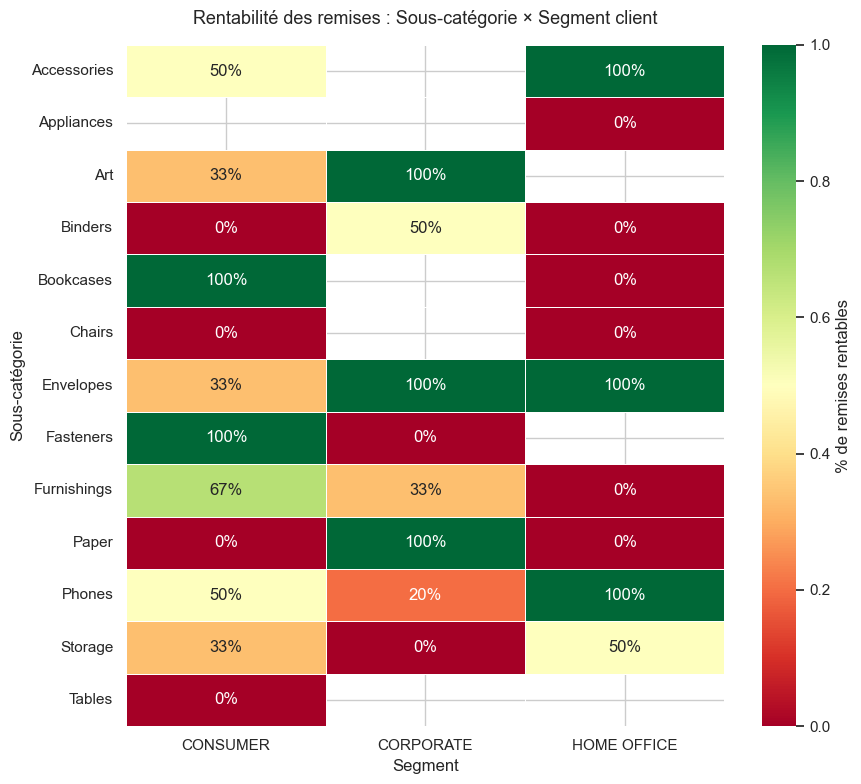

In [14]:
# Heatmap : Rentabilité moyenne par Sous-catégorie × Segment
pivot = df_remise.pivot_table(
    values='remise_rentable',
    index='Sub-Category',
    columns='Segment',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% de remises rentables'}
)
ax.set_title('Rentabilité des remises : Sous-catégorie × Segment client', pad=15)
ax.set_ylabel('Sous-catégorie')
ax.set_xlabel('Segment')
plt.tight_layout()
plt.savefig('plots/heatmap_rentabilite.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Simulation — Seuil optimal de remise

Pour chaque catégorie, on identifie le **taux de remise maximum** avant que les remises deviennent systématiquement non rentables.

=== Seuil de remise recommandé par catégorie ===
  Furniture            → max 0%
  Office Supplies      → max 0%
  Technology           → max 20%


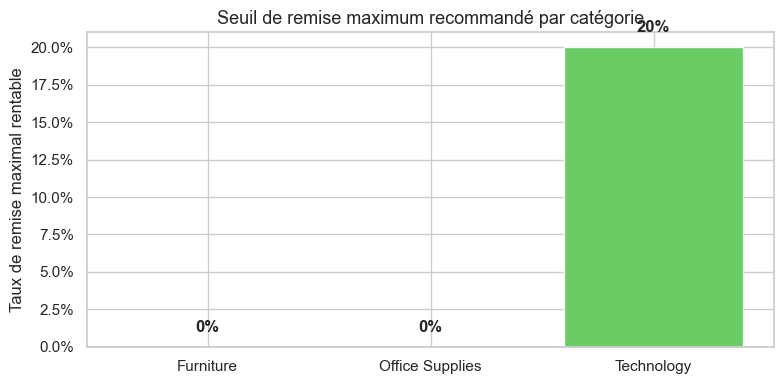

In [15]:
seuils = {}
for cat in df_remise['Category'].unique():
    sub = df_remise[df_remise['Category'] == cat].copy()
    # On cherche le taux de remise à partir duquel < 50% des commandes sont rentables
    for seuil in np.arange(0.05, 1.0, 0.05):
        taux = sub[sub['Discount'] >= seuil]['remise_rentable'].mean()
        if pd.isna(taux) or taux < 0.5:
            seuils[cat] = round(seuil - 0.05, 2)
            break
    else:
        seuils[cat] = 0.95

print('=== Seuil de remise recommandé par catégorie ===')
for cat, seuil in seuils.items():
    print(f'  {cat:20s} → max {seuil:.0%}')

fig, ax = plt.subplots(figsize=(8, 4))
cats = list(seuils.keys())
vals = [seuils[c] for c in cats]
bars = ax.bar(cats, vals, color=sns.color_palette('muted', len(cats)))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Seuil de remise maximum recommandé par catégorie')
ax.set_ylabel('Taux de remise maximal rentable')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.0%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/seuil_remise.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 📝 Synthèse & Recommandations

In [16]:
print('=' * 55)
print('        SYNTHÈSE DE L\'ANALYSE')
print('=' * 55)

total_remises = len(df_remise)
pct_rentable = df_remise['remise_rentable'].mean()
perte_totale = df_remise['perte_remise'].sum()
perte_non_rentable = df_remise[df_remise['remise_rentable'] == 0]['perte_remise'].sum()

print(f'\n📦 Commandes avec remise analysées : {total_remises}')
print(f'✅ Remises rentables               : {pct_rentable:.1%}')
print(f'❌ Remises non rentables           : {1 - pct_rentable:.1%}')
print(f'\n💸 Perte totale due aux remises    : ${perte_totale:,.0f}')
print(f'💸 Dont perte non justifiée        : ${perte_non_rentable:,.0f}')

print(f'\n🤖 Précision du modèle (CV)        : {cv_scores.mean():.1%}')
print(f'\n📌 Top feature déterminante        : {importances.idxmax()}')
print('\n' + '=' * 55)
print('\n💡 RECOMMANDATIONS :')
print('  1. Limiter les remises selon les seuils identifiés')
print('     par catégorie (cf. graphique section 8)')
print('  2. Cibler en priorité les clients Corporate')
print('     et les produits Technology pour les remises')
print('  3. Éviter les remises > 50% sur Furniture/Tables')
print('     sauf commandes très volumineuses')

        SYNTHÈSE DE L'ANALYSE

📦 Commandes avec remise analysées : 73
✅ Remises rentables               : 28.8%
❌ Remises non rentables           : 71.2%

💸 Perte totale due aux remises    : $5,322
💸 Dont perte non justifiée        : $2,408

🤖 Précision du modèle (CV)        : 68.6%

📌 Top feature déterminante        : Quantity


💡 RECOMMANDATIONS :
  1. Limiter les remises selon les seuils identifiés
     par catégorie (cf. graphique section 8)
  2. Cibler en priorité les clients Corporate
     et les produits Technology pour les remises
  3. Éviter les remises > 50% sur Furniture/Tables
     sauf commandes très volumineuses
